# 03 — Modèles Candidats
**Projet** : ObRail MSPR 2025-2026  

**Source** : `data/processed/X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv`  

**Objectif** : Entraîner, évaluer et comparer quatre modèles candidats sur la tâche de classification binaire `is_underserved`. Sélectionner et sauvegarder le meilleur modèle.

**Modèles testés** :
1. Régression Logistique — baseline interprétable
2. Random Forest — ensemble d'arbres, robuste au bruit
3. LightGBM — gradient boosting optimisé
4. MLP (Multi-Layer Perceptron) — réseau de neurones simple

**Métriques principales** : F1-score (classe 1) et ROC-AUC  
**Stratégie déséquilibre** : `class_weight='balanced'` sur tous les modèles qui le supportent

## 0. Imports et configuration

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
)
from sklearn.model_selection import cross_val_score, StratifiedKFold

SEED = 42
np.random.seed(SEED)


def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for folder in [cwd] + list(cwd.parents):
        if (folder / 'data').exists() and (folder / 'src').exists() and (folder / 'models').exists():
            return folder
    raise FileNotFoundError('Could not find project root from current working directory')

ROOT = find_project_root()
PROCESSED_DIR = ROOT / 'data' / 'processed'
MODELS_DIR = ROOT / 'models'
PLOT_DIR = ROOT / 'evaluation' / 'plots'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print('✅ Imports OK')

✅ Imports OK


## 1. Chargement des données

In [2]:
X_train = pd.read_csv(PROCESSED_DIR / 'X_train.csv')
X_test  = pd.read_csv(PROCESSED_DIR / 'X_test.csv')
y_train = pd.read_csv(PROCESSED_DIR / 'y_train.csv').squeeze()
y_test  = pd.read_csv(PROCESSED_DIR / 'y_test.csv').squeeze()

print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')
print(f'Taux underserved train : {y_train.mean()*100:.1f}%')
print(f'Taux underserved test  : {y_test.mean()*100:.1f}%')

X_train : (20160, 38)
X_test  : (5040, 38)
Taux underserved train : 19.4%
Taux underserved test  : 19.4%


## 2. Justification des modèles choisis

| Modèle | Famille | Justification | Limite |
|--------|---------|---------------|--------|
| Régression Logistique | Linéaire | Baseline interprétable, coefficients lisibles, rapide à entraîner | Suppose une séparation linéaire — sous-optimal si les relations sont non-linéaires |
| Random Forest | Ensemble d'arbres | Robuste au bruit, gère bien les interactions entre features, peu sensible à la normalisation | Plus lent, moins interprétable que LR |
| LightGBM | Gradient Boosting | État de l'art sur données tabulaires, rapide, gère le déséquilibre via `scale_pos_weight` | Nécessite un tuning d'hyperparamètres pour donner le meilleur de lui-même |
| MLP | Réseau de neurones | Capture des relations non-linéaires complexes, flexible | Sensible à la normalisation (déjà faite), nécessite plus de données et de tuning |

## 3. Définition des modèles

Tous les modèles utilisent `class_weight='balanced'` ou son équivalent pour gérer le déséquilibre 4:1.  
Le ratio exact pour LightGBM (`scale_pos_weight`) est calculé à partir de y_train.

In [3]:
# Ratio pour LightGBM : nombre de négatifs / nombre de positifs
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f'scale_pos_weight pour LightGBM : {scale_pos_weight:.2f}')

models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=SEED,
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=SEED,
        n_jobs=-1,
    ),
    'LightGBM': LGBMClassifier(
        scale_pos_weight=scale_pos_weight,
        n_estimators=200,
        random_state=SEED,
        n_jobs=-1,
        verbose=-1,
    ),
    'MLP': MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation='relu',
        max_iter=300,
        random_state=SEED,
        early_stopping=True,
        validation_fraction=0.1,
    ),
}

print(f'\n{len(models)} modèles définis :')
for name in models:
    print(f'  - {name}')

scale_pos_weight pour LightGBM : 4.16

4 modèles définis :
  - Logistic Regression
  - Random Forest
  - LightGBM
  - MLP


## 4. Entraînement et évaluation

Pour chaque modèle :
1. Cross-validation 5-fold sur X_train (F1 + ROC-AUC) — évalue la stabilité
2. Entraînement sur X_train complet
3. Évaluation finale sur X_test — résultat honnête sur données jamais vues

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
results = {}

# Redéfinition des modèles avec n_jobs=1 pour éviter le blocage en notebook
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=SEED,
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=SEED,
        n_jobs=1,
    ),
    'LightGBM': LGBMClassifier(
        scale_pos_weight=scale_pos_weight,
        n_estimators=200,
        random_state=SEED,
        n_jobs=1,
        verbose=-1,
    ),
    'MLP': MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation='relu',
        max_iter=300,
        random_state=SEED,
        early_stopping=True,
        validation_fraction=0.1,
    ),
}

for name, model in models.items():
    print(f'\n{"="*50}')
    print(f'  {name}')
    print(f'{"="*50}')

    cv_f1  = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1', n_jobs=1)
    cv_auc = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=1)
    print(f'CV F1      : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')
    print(f'CV ROC-AUC : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')

    model.fit(X_train, y_train)

    y_pred       = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    test_f1  = f1_score(y_test, y_pred)
    test_auc = roc_auc_score(y_test, y_pred_proba)

    print(f'Test F1    : {test_f1:.4f}')
    print(f'Test AUC   : {test_auc:.4f}')
    print(f'\nClassification report :')
    print(classification_report(y_test, y_pred,
          target_names=['Non sous-desservi', 'Sous-desservi']))

    results[name] = {
        'cv_f1_mean':   cv_f1.mean(),
        'cv_f1_std':    cv_f1.std(),
        'cv_auc_mean':  cv_auc.mean(),
        'cv_auc_std':   cv_auc.std(),
        'test_f1':      test_f1,
        'test_auc':     test_auc,
        'y_pred':       y_pred,
        'y_pred_proba': y_pred_proba,
        'model':        model,
    }

print('\n✅ Tous les modèles entraînés')


  Logistic Regression
CV F1      : 0.5782 ± 0.0121
CV ROC-AUC : 0.8688 ± 0.0045
Test F1    : 0.5680
Test AUC   : 0.8653

Classification report :
                   precision    recall  f1-score   support

Non sous-desservi       0.93      0.78      0.85      4063
    Sous-desservi       0.46      0.75      0.57       977

         accuracy                           0.78      5040
        macro avg       0.69      0.77      0.71      5040
     weighted avg       0.84      0.78      0.80      5040


  Random Forest
CV F1      : 0.5722 ± 0.0070
CV ROC-AUC : 0.8738 ± 0.0050
Test F1    : 0.5817
Test AUC   : 0.8707

Classification report :
                   precision    recall  f1-score   support

Non sous-desservi       0.92      0.82      0.87      4063
    Sous-desservi       0.49      0.72      0.58       977

         accuracy                           0.80      5040
        macro avg       0.71      0.77      0.72      5040
     weighted avg       0.84      0.80      0.81      5040



## 5. Tableau comparatif des modèles

In [5]:
comparison = pd.DataFrame([
    {
        'Modèle':         name,
        'CV F1 (mean)':   f"{r['cv_f1_mean']:.4f}",
        'CV F1 (±std)':   f"{r['cv_f1_std']:.4f}",
        'CV AUC (mean)':  f"{r['cv_auc_mean']:.4f}",
        'CV AUC (±std)':  f"{r['cv_auc_std']:.4f}",
        'Test F1':        f"{r['test_f1']:.4f}",
        'Test AUC':       f"{r['test_auc']:.4f}",
    }
    for name, r in results.items()
])

comparison = comparison.sort_values('Test F1', ascending=False).reset_index(drop=True)

print('Tableau comparatif des modèles :')
display(comparison)

comparison.to_csv('../evaluation/model_comparison.csv', index=False)
print('\n✅ Sauvegardé → evaluation/model_comparison.csv')

Tableau comparatif des modèles :


,Modèle,CV F1 (mean),CV F1 (±std),CV AUC (mean),CV AUC (±std),Test F1,Test AUC
0,LightGBM,0.6119,0.0075,0.8820,0.0036,0.6050,0.8826
1,Random Forest,0.5722,0.0070,0.8738,0.0050,0.5817,0.8707
2,Logistic Regression,0.5782,0.0121,0.8688,0.0045,0.5680,0.8653
3,MLP,0.3681,0.0955,0.8848,0.0044,0.3863,0.8815



✅ Sauvegardé → evaluation/model_comparison.csv


## 6. Visualisations

### 6.1 Comparaison F1 et ROC-AUC

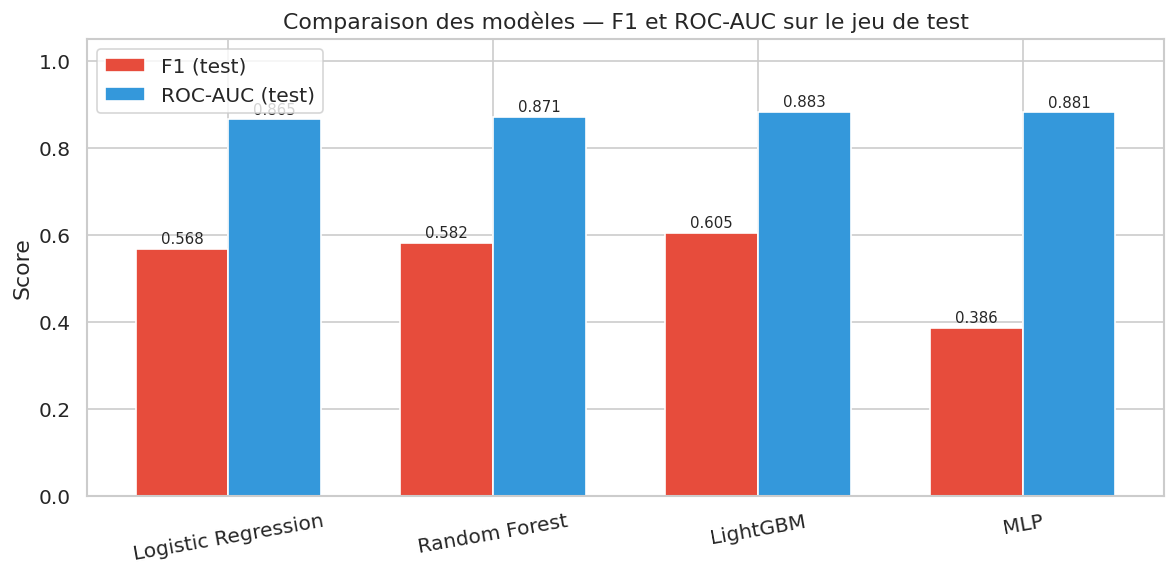

In [6]:
names     = list(results.keys())
test_f1s  = [results[n]['test_f1']  for n in names]
test_aucs = [results[n]['test_auc'] for n in names]

x = np.arange(len(names))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - w/2, test_f1s,  width=w, label='F1 (test)',      color='#e74c3c')
bars2 = ax.bar(x + w/2, test_aucs, width=w, label='ROC-AUC (test)', color='#3498db')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=10)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Comparaison des modèles — F1 et ROC-AUC sur le jeu de test')
ax.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / 'model_comparison.png')
plt.show()

### 6.2 Courbes ROC

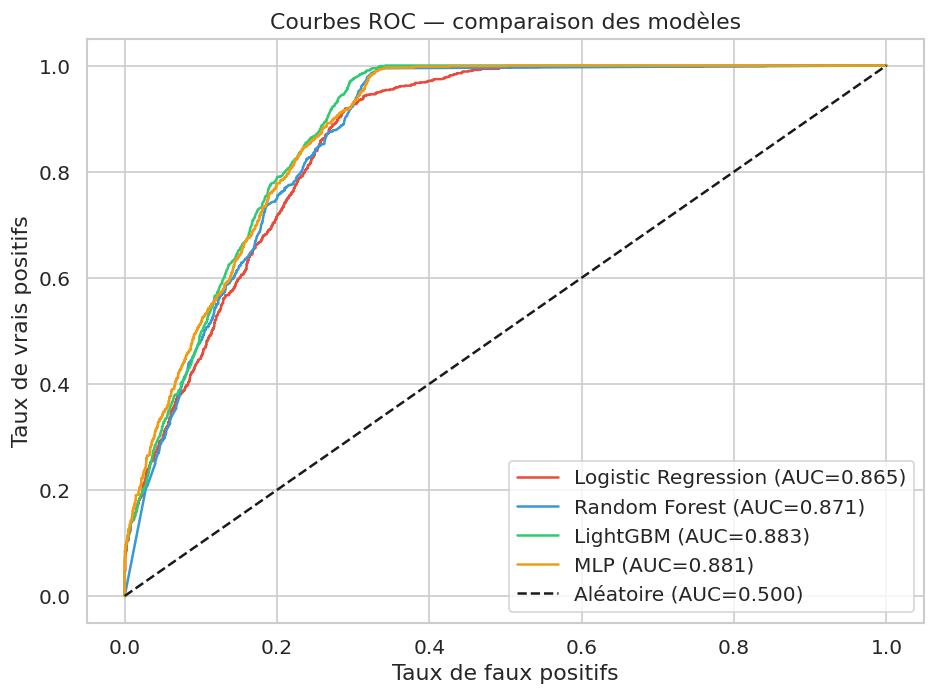

In [7]:
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

fig, ax = plt.subplots(figsize=(8, 6))

for (name, r), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, r['y_pred_proba'])
    ax.plot(fpr, tpr, color=color,
            label=f"{name} (AUC={r['test_auc']:.3f})")

ax.plot([0, 1], [0, 1], 'k--', label='Aléatoire (AUC=0.500)')
ax.set_xlabel('Taux de faux positifs')
ax.set_ylabel('Taux de vrais positifs')
ax.set_title('Courbes ROC — comparaison des modèles')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'roc_curves.png')
plt.show()

### 6.3 Courbes Précision-Rappel

Plus informative que la courbe ROC en cas de déséquilibre de classes — elle montre le compromis entre précision (éviter les faux positifs) et rappel (ne pas manquer de vraies routes sous-desservies).

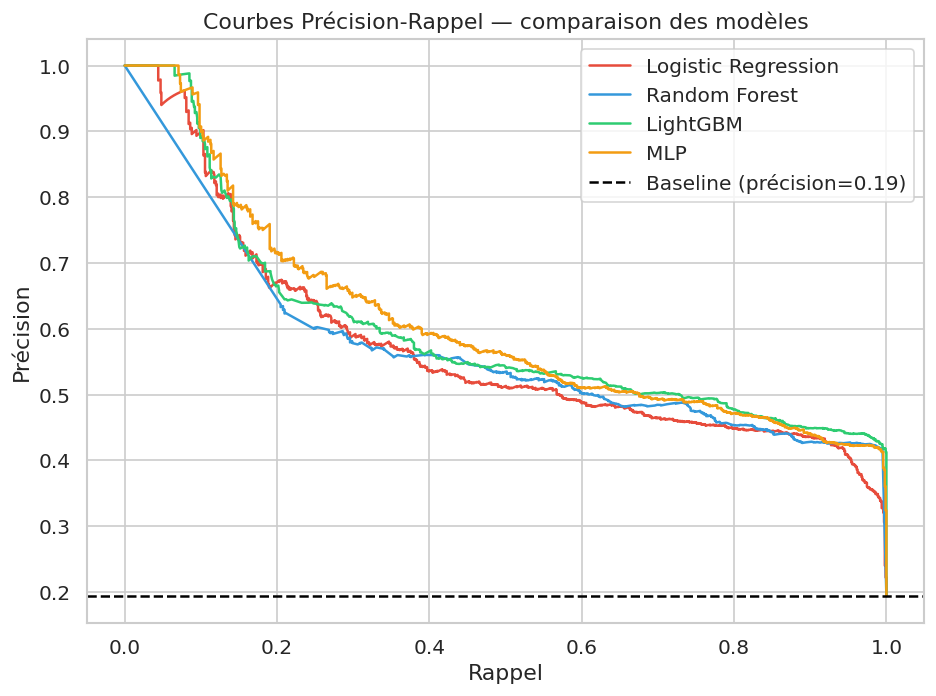

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))

for (name, r), color in zip(results.items(), colors):
    prec, rec, _ = precision_recall_curve(y_test, r['y_pred_proba'])
    ax.plot(rec, prec, color=color, label=name)

baseline = y_test.mean()
ax.axhline(baseline, color='black', linestyle='--',
           label=f'Baseline (précision={baseline:.2f})')
ax.set_xlabel('Rappel')
ax.set_ylabel('Précision')
ax.set_title('Courbes Précision-Rappel — comparaison des modèles')
ax.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / 'precision_recall_curves.png')
plt.show()

### 6.4 Matrices de confusion

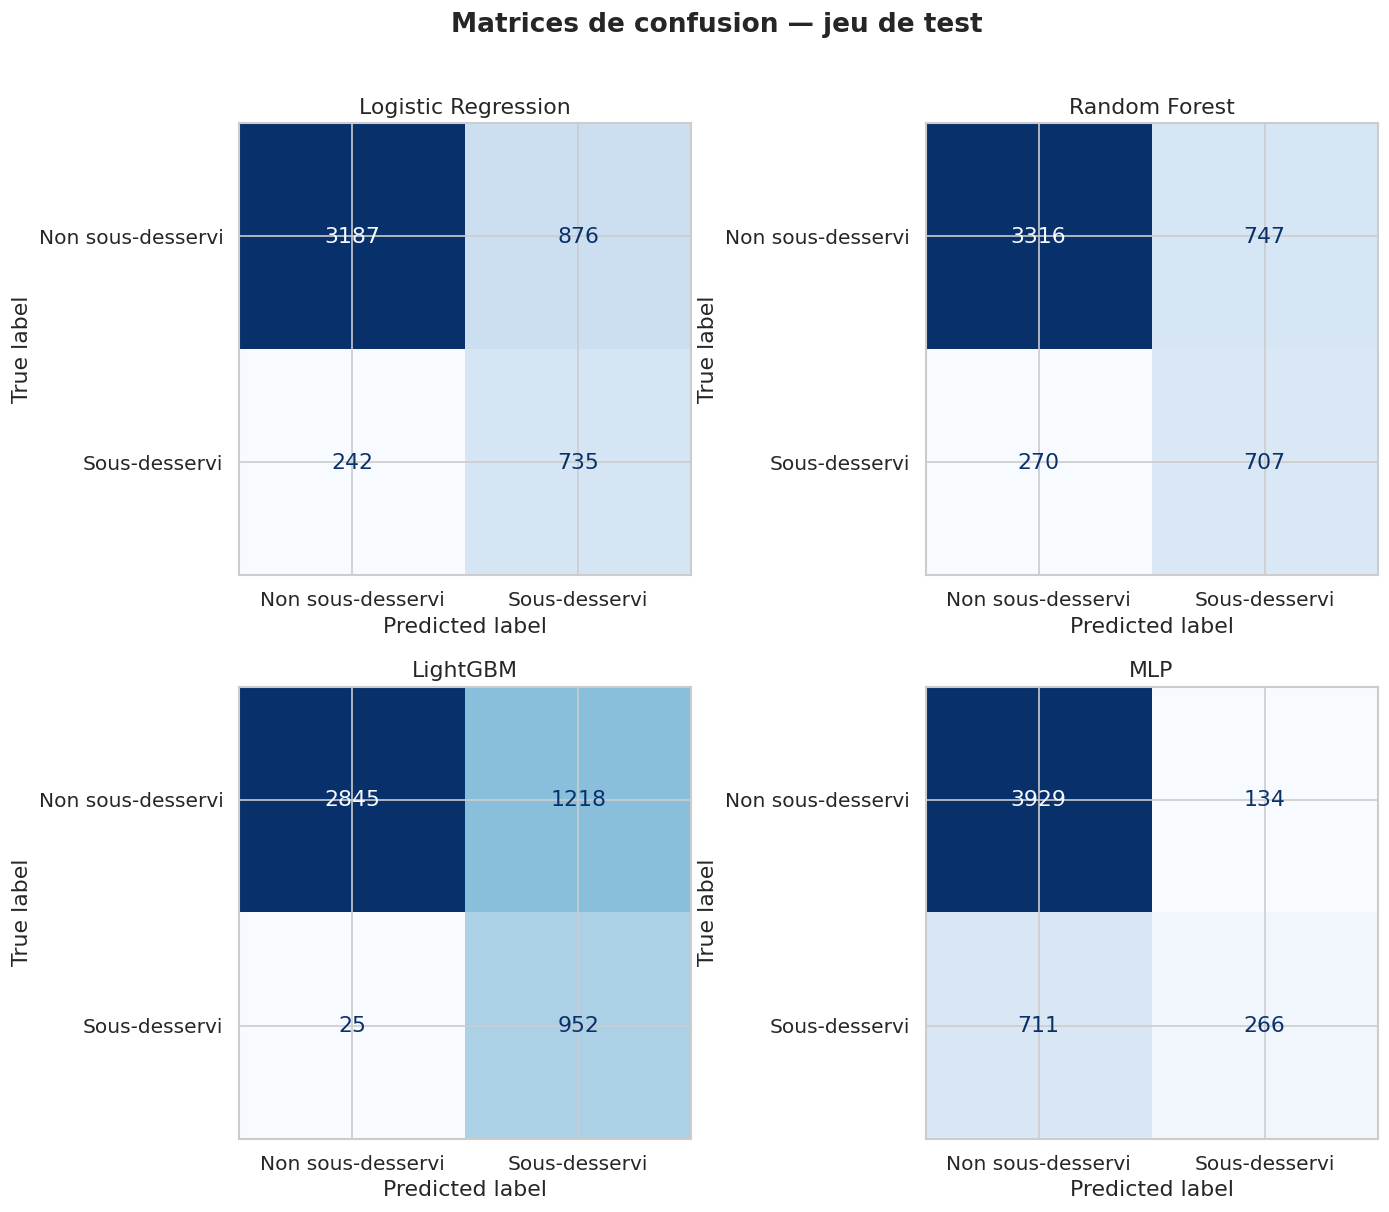

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (name, r) in enumerate(results.items()):
    cm = confusion_matrix(y_test, r['y_pred'])
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Non sous-desservi', 'Sous-desservi']
    )
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(name)

plt.suptitle('Matrices de confusion — jeu de test', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'confusion_matrices.png', bbox_inches='tight')
plt.show()

## 7. Sélection du modèle final

**Critère de sélection** : F1-score sur le jeu de test (métrique principale choisie en EDA pour tenir compte du déséquilibre de classes).  
En cas d'égalité, on privilégie le ROC-AUC puis la stabilité (faible écart-type en CV).

In [10]:
best_name = max(results, key=lambda n: results[n]['test_f1'])
best_model = results[best_name]['model']
best_f1    = results[best_name]['test_f1']
best_auc   = results[best_name]['test_auc']

print(f'✅ Modèle sélectionné : {best_name}')
print(f'   Test F1      : {best_f1:.4f}')
print(f'   Test ROC-AUC : {best_auc:.4f}')
print(f'\nJustification : meilleur F1 sur le jeu de test parmi les 4 modèles candidats.')
print(f'Le F1 est la métrique principale retenue car le dataset est déséquilibré (4:1).')

✅ Modèle sélectionné : LightGBM
   Test F1      : 0.6050
   Test ROC-AUC : 0.8826

Justification : meilleur F1 sur le jeu de test parmi les 4 modèles candidats.
Le F1 est la métrique principale retenue car le dataset est déséquilibré (4:1).


## 8. Sauvegarde du modèle final

In [11]:
model_path = MODELS_DIR / 'best_model.joblib'
joblib.dump(best_model, model_path)

# Sauvegarde des métadonnées du modèle
metadata = {
    'model_name':   best_name,
    'test_f1':      round(best_f1, 4),
    'test_roc_auc': round(best_auc, 4),
    'features':     list(X_train.columns),
    'target':       'is_underserved',
    'n_train':      len(X_train),
    'n_test':       len(X_test),
    'seed':         SEED,
}

import json
with open(MODELS_DIR / 'model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(f'✅ Modèle sauvegardé → {model_path}')
print(f'✅ Métadonnées sauvegardées → models/model_metadata.json')
print(f'\nContenu metadata :')
print(json.dumps(metadata, indent=2))

✅ Modèle sauvegardé → /mnt/c/Users/charl/Desktop/EPSI-IA/MSPR/MSPR - 2/OBRail-MSPR2/models/best_model.joblib
✅ Métadonnées sauvegardées → models/model_metadata.json

Contenu metadata :
{
  "model_name": "LightGBM",
  "test_f1": 0.605,
  "test_roc_auc": 0.8826,
  "features": [
    "rail_modal_share",
    "type_encoded",
    "is_international",
    "log_distance",
    "log_co2",
    "country_AT",
    "country_BE",
    "country_BG",
    "country_CH",
    "country_CZ",
    "country_DE",
    "country_DK",
    "country_EE",
    "country_ES",
    "country_FI",
    "country_FR",
    "country_GB",
    "country_GR",
    "country_HR",
    "country_HU",
    "country_IE",
    "country_IT",
    "country_LT",
    "country_LU",
    "country_MD",
    "country_ME",
    "country_MK",
    "country_NL",
    "country_NO",
    "country_PL",
    "country_PT",
    "country_RO",
    "country_RS",
    "country_SE",
    "country_SI",
    "country_SK",
    "country_TR",
    "country_UA"
  ],
  "target": "is_unders

## 9. Récapitulatif et prochaines étapes

**Ce qui a été fait**
- 4 modèles entraînés et évalués : Logistic Regression, Random Forest, LightGBM, MLP
- Cross-validation 5-fold sur chaque modèle
- Évaluation finale sur jeu de test : F1, ROC-AUC, matrices de confusion, courbes ROC et PR
- Tableau comparatif sauvegardé → `evaluation/model_comparison.csv`
- Meilleur modèle sauvegardé → `models/best_model.joblib`

**Limites documentées**
- Les modèles sont entraînés avec des hyperparamètres par défaut — un tuning via GridSearch/RandomSearch est prévu dans `src/optimize.py`
- `log_distance` reste une feature à surveiller via SHAP (corrélation partielle avec la règle cible)
- Le MLP nécessite une normalisation préalable — déjà effectuée en `02_feature_engineering.ipynb`

**Prochaines étapes**
- `src/optimize.py` — optimisation des hyperparamètres du meilleur modèle
- `notebooks/05_explainability.ipynb` — SHAP et LIME sur le modèle final
- `src/predict.py` — script de prédiction standalone
- `api/main.py` — API FastAPI `/predict`